In [1]:
from pathlib import Path
import xarray as xr

from utils import get_MVBS_tensor, get_hake_model

import torch

import echopype as ep

In [2]:
path_MVBS = "/Volumes/sh2506_ext1/leg1_test/MVBS"
MVBS_files = sorted(list(Path(path_MVBS).glob("*.zarr")))
len(MVBS_files)

170

In [20]:
MVBS_files[-4:]

[PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250615T180000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250615T182000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250615T184000.zarr'),
 PosixPath('/Volumes/sh2506_ext1/leg1_test/MVBS/MVBS_20250615T190000.zarr')]

In [4]:
# Combine MVBS files into a single dataset
ds_MVBS_combine = xr.open_mfdataset(
    MVBS_files[-4:],
    parallel=True,
    coords="minimal",
    data_vars="minimal",
    compat='override',
    chunks={"channel": -1, "ping_time": -1, "depth": -1},  # load everything into 1 chunk
    engine="zarr",  # use zarr engine for reading
).sel(
    # slice start/end, end exclusive
    # ping_time=slice(start_time, end_time-pd.to_timedelta("10milliseconds")),
    depth=slice(None, 590)  # slice to what the model expects
)

In [5]:
input_tensor = get_MVBS_tensor(ds_MVBS_combine)

In [6]:
ds_MVBS_combine

<xarray.Dataset> Size: 22MB
Dimensions:            (channel: 5, ping_time: 939, depth: 591)
Coordinates:
  * channel            (channel) <U25 500B 'WBT 400140-15 ES120-7C_ES' ... 'W...
  * depth              (depth) float64 5kB 0.0 1.0 2.0 3.0 ... 588.0 589.0 590.0
  * ping_time          (ping_time) datetime64[ns] 8kB 2025-06-15T18:00:00 ......
Data variables:
    Sv                 (channel, ping_time, depth) float64 22MB dask.array<chunksize=(5, 240, 591), meta=np.ndarray>
    frequency_nominal  (channel) float64 40B dask.array<chunksize=(5,), meta=np.ndarray>
    latitude           (ping_time) float64 8kB dask.array<chunksize=(240,), meta=np.ndarray>
    longitude          (ping_time) float64 8kB dask.array<chunksize=(240,), meta=np.ndarray>
Attributes:
    processing_function:          commongrid.compute_MVBS
    processing_level:             Level 3A
    processing_level_url:         https://echopype.readthedocs.io/en/stable/p...
    processing_software_name:     echopype
    processing_software_version:  0.10.1
    processing_time:              2025-06-15T18:53:01Z

In [7]:
input_tensor.shape

torch.Size([1, 3, 591, 939])

In [8]:
# Load binary hake models with weights
model_epoch = 85
model_folder = "/Users/feresa/code_git/echodataflow/temp_model/model_160_epochs/model_weights"
model_path = f"{model_folder}/binary_hake_model_1.0m_bottom_offset_1.0m_depth_2017_2019_epoch_{model_epoch:03d}.ckpt"
model = get_hake_model(model_path)

In [9]:
temperature = 0.5
softmax_threshold = 0.5

In [10]:
score_tensor = model(input_tensor).detach().squeeze(0)
score_tensor_softmax = torch.nn.functional.softmax(score_tensor / temperature, dim=0)

In [11]:
# Assemble output DataArrays
da_score = xr.DataArray(
    score_tensor,
    coords={
        "scatterer_class": ["background", "hake"],
        "depth": ds_MVBS_combine["depth"].values,
        "ping_time": ds_MVBS_combine["ping_time"].values,
    },
    name="score",
)
da_score_softmax = xr.DataArray(
    score_tensor_softmax,
    coords={
        "scatterer_class": ["background", "hake"],
        "depth": ds_MVBS_combine["depth"].values,
        "ping_time": ds_MVBS_combine["ping_time"].values,
    },
    name="softmax_score",
)

In [12]:
da_score

<xarray.DataArray 'score' (scatterer_class: 2, depth: 591, ping_time: 939)> Size: 4MB
array([[[ 3.8794498,  3.95109  ,  4.0227304, ...,  3.6905866,
          3.6713521,  3.6521175],
        [ 3.9536211,  4.0300484,  4.106476 , ...,  3.7787938,
          3.7557764,  3.732759 ],
        [ 4.0277925,  4.109007 ,  4.1902213, ...,  3.8670013,
          3.840201 ,  3.8134003],
        ...,
        [ 4.180327 ,  4.2988977,  4.417468 , ...,  4.5069942,
          4.4254704,  4.343946 ],
        [ 4.1149397,  4.2288346,  4.3427296, ...,  4.4242873,
          4.346903 ,  4.2695184],
        [ 4.0495486,  4.1587677,  4.267987 , ...,  4.3415756,
          4.268331 ,  4.1950865]],

       [[-4.020961 , -4.0847654, -4.14857  , ..., -3.8607447,
         -3.8502944, -3.8398442],
        [-4.081779 , -4.14979  , -4.2178006, ..., -3.929946 ,
         -3.915958 , -3.9019704],
        [-4.1425967, -4.214814 , -4.2870317, ..., -3.9991472,
         -3.9816215, -3.9640963],
        ...,
        [-4.1282206, -4.22743  , -4.3266387, ..., -4.51025  ,
         -4.445425 , -4.3806   ],
        [-4.080219 , -4.174461 , -4.2687035, ..., -4.4380617,
         -4.3772597, -4.3164573],
        [-4.032214 , -4.121489 , -4.210764 , ..., -4.365869 ,
         -4.30909  , -4.2523108]]], dtype=float32)
Coordinates:
  * scatterer_class  (scatterer_class) <U10 80B 'background' 'hake'
  * depth            (depth) float64 5kB 0.0 1.0 2.0 3.0 ... 588.0 589.0 590.0
  * ping_time        (ping_time) datetime64[ns] 8kB 2025-06-15T18:00:00 ... 2...

In [13]:
da_score_softmax

<xarray.DataArray 'softmax_score' (scatterer_class: 2, depth: 591,
                                   ping_time: 939)> Size: 4MB
array([[[9.99999881e-01, 9.99999881e-01, 9.99999881e-01, ...,
         9.99999762e-01, 9.99999762e-01, 9.99999642e-01],
        [9.99999881e-01, 9.99999881e-01, 1.00000000e+00, ...,
         9.99999762e-01, 9.99999762e-01, 9.99999762e-01],
        [9.99999881e-01, 1.00000000e+00, 1.00000000e+00, ...,
         9.99999881e-01, 9.99999881e-01, 9.99999881e-01],
        ...,
        [9.99999881e-01, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
        [9.99999881e-01, 1.00000000e+00, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.00000000e+00],
        [9.99999881e-01, 9.99999881e-01, 1.00000000e+00, ...,
         1.00000000e+00, 1.00000000e+00, 1.00000000e+00]],

       [[1.37337921e-07, 1.04747755e-07, 7.98910591e-08, ...,
         2.76055687e-07, 2.92941422e-07, 3.10859946e-07],
        [1.04843096e-07, 7.85385339e-08, 5.88336455e-08, ...,
         2.01499333e-07, 2.16978208e-07, 2.33645920e-07],
        [8.00368696e-08, 5.88871956e-08, 4.33263025e-08, ...,
         1.47078836e-07, 1.60713199e-07, 1.75611305e-07],
        ...,
        [6.07137238e-08, 3.92759176e-08, 2.54077257e-08, ...,
         1.47136721e-08, 1.97168788e-08, 2.64213647e-08],
        [7.61686323e-08, 5.02331332e-08, 3.31286927e-08, ...,
         2.00568095e-08, 2.64416311e-08, 3.48591129e-08],
        [9.55587325e-08, 6.42481695e-08, 4.31967564e-08, ...,
         2.73406755e-08, 3.54606442e-08, 4.59921807e-08]]], dtype=float32)
Coordinates:
  * scatterer_class  (scatterer_class) <U10 80B 'background' 'hake'
  * depth            (depth) float64 5kB 0.0 1.0 2.0 3.0 ... 588.0 589.0 590.0
  * ping_time        (ping_time) datetime64[ns] 8kB 2025-06-15T18:00:00 ... 2...

In [14]:
ds_MVBS_combine = ep.consolidate.swap_dims_channel_frequency(ds_MVBS_combine)

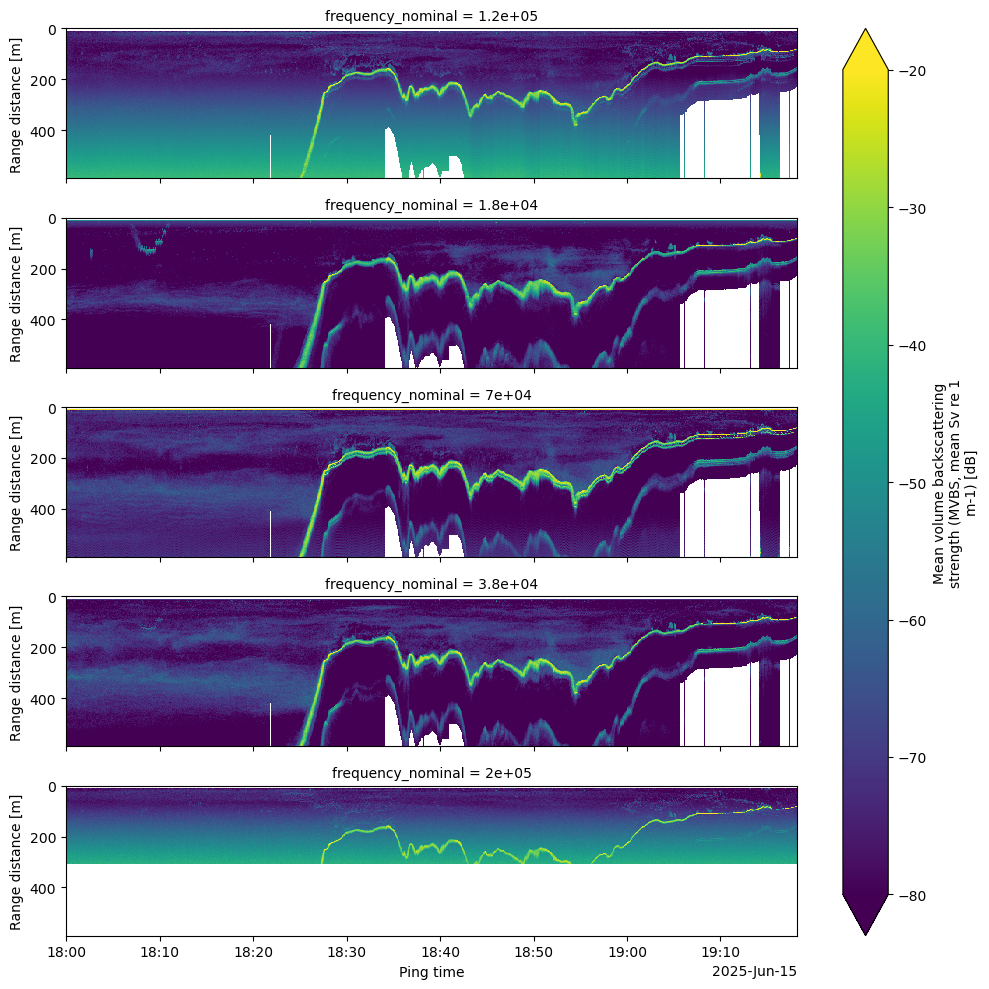

In [15]:
ds_MVBS_combine["Sv"].plot(
    x="ping_time", y="depth",
    row="frequency_nominal", col_wrap=1,
    figsize=(10, 10),
    cmap="viridis", vmin=-80, vmax=-20, yincrease=False,
)

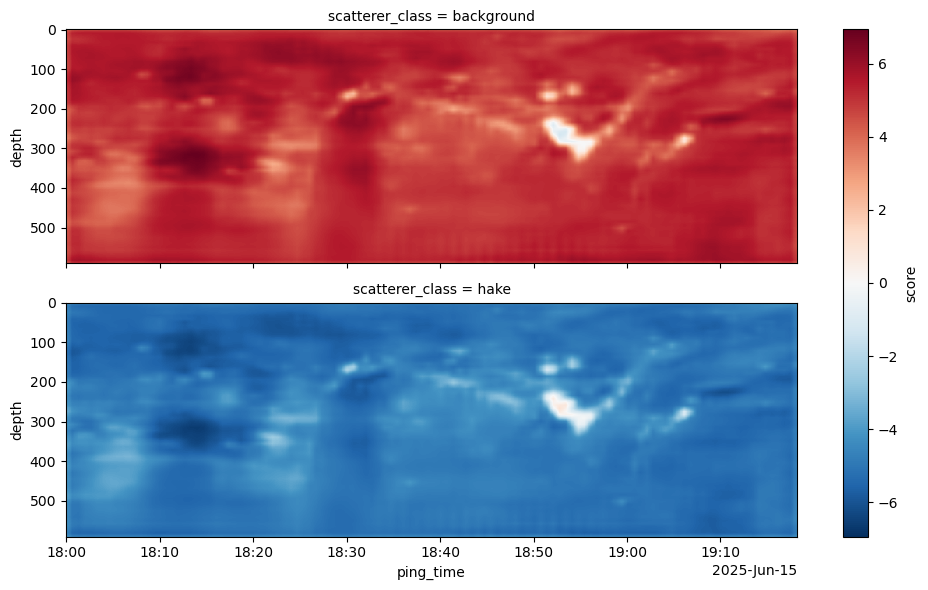

In [16]:
da_score.plot(
    x="ping_time", y="depth",
    row="scatterer_class", col_wrap=1,
    figsize=(10, 6), yincrease=False,
    # cmap="viridis", vmin=-80, vmax=-20, 
)

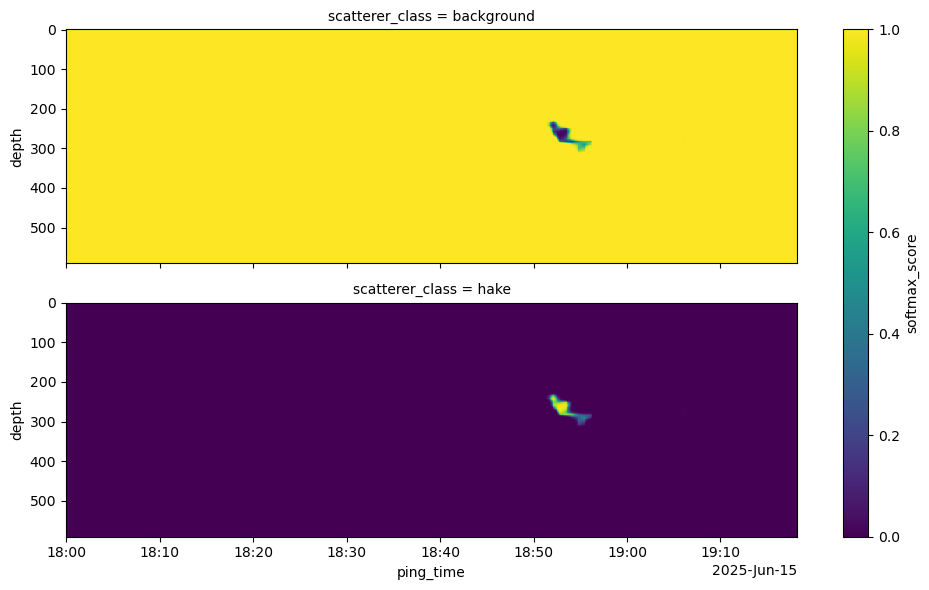

In [17]:
da_score_softmax.plot(
    x="ping_time", y="depth",
    row="scatterer_class", col_wrap=1,
    figsize=(10, 6), yincrease=False,
    # cmap="viridis", vmin=-80, vmax=-20, 
)